In [7]:
import ollama 
import os
from tqdm import tqdm
import json
import signal
import argparse
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import copy
import sys
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

#from  utilities import *

In [8]:
sys.argv = [
    'notebook',  
    '--modelname', 'llama3.2-vision:90b',
    '--data', 'gully',
    '--data_path','/home/data/',
    "--data_samples", 'train.jsonl',
    "--subset", 'train',
    '--results_dir', '/mnt/jacket/WACV-2025-Workshop-ViGIR/results/proposed',
    '--timeout', '20',
    '--model_unloading'
]

In [9]:
parser = argparse.ArgumentParser(description="A script to run V-LLMs on different image classification datasets")

In [10]:
# set up the argument parser
parser.add_argument("--modelname", type=str, required=True, help="The name of the V-LLM model")
parser.add_argument("--data", type=str, required=True, help="Dataset name")
parser.add_argument("--data_path", type=str, required=True, help="Path to the image data dir")
parser.add_argument("--data_samples", type=str, required=True, help="Name of the samples to run on")
parser.add_argument("--subset", type=str, required=True, help="train, test or validation set")
parser.add_argument("--results_dir", type=str, required=True, help="Folder name to save results")
parser.add_argument("--timeout", type=int, default=40, help="time out duration to skip one sample")
parser.add_argument("--model_unloading", action="store_true", help="Enables unloading mode. Every 100 sampels it unloades the model from the GPU to avoid carshing.")


args = parser.parse_args()

In [11]:
# Load test set:
file_path = 'Testing_Set.json'
#file_path = 'Validation_Set.json'
with open(file_path, 'r') as file:
    data = json.load(file)

print('Number of Annotated GT Images: ', len(data.keys()))
data_keys_test = list(data.keys())
print('Number of Annotated GT Images (List): ', len(data_keys_test))

Number of Annotated GT Images:  311
Number of Annotated GT Images (List):  311


In [26]:
# Load results from a specifc model
#filename = 'valid_'+args.modelname+'.json'
#filename = 'valid_llama3_90b.json'
#filename = 'test_Qwen2-VL-72B-Instruct-QAs.json'
filename = 'test_19Q_llama3.2-vision:90b.json'
with open((os.path.join(args.results_dir, filename)), 'r') as file:
    result_data = json.load(file)

print('Results from: ', args.modelname)
print('Number of Images: ', len(result_data.keys()))
result_data_keys = list(result_data.keys())
print('Number of Images (List): ', len(result_data_keys))

Results from:  llama3.2-vision:90b
Number of Images:  311
Number of Images (List):  311


In [27]:
result_data

{'415': [[{'label': '4', 'labelers': ['Ali', 'Dr.Lory']},
   'Given these six images of the exact same area and collected over a period of 10 years, do you see a low point in the terrain? Answer with yes or no only!',
   'No.'],
  [{'label': '4', 'labelers': ['Ali', 'Dr.Lory']},
   'Given these six images of the exact same area and collected over a period of 10 years, do narrow, winding paths or channels appear? Answer with yes or no only!',
   'No.'],
  [{'label': '4', 'labelers': ['Ali', 'Dr.Lory']},
   'Given these six images of the exact same area and collected over a period of 10 years, are there winding paths that become intermittent recurrent? Answer with yes or no only!',
   'No.'],
  [{'label': '4', 'labelers': ['Ali', 'Dr.Lory']},
   'Given these six images of the exact same area and collected over a period of 10 years, are there any linear depressions or ruts which appear more pronounced along natural drainage lines or slopes? Answer with yes or no only!',
   'No.'],
  [{'la

In [28]:
num_questions = 19
histogram_gully = {i: 0 for i in range(num_questions)}
histogram_not_gully = {i: 0 for i in range(num_questions)}
no_histogram_gully = {i: 0 for i in range(num_questions)}
no_histogram_not_gully = {i: 0 for i in range(num_questions)}

In [29]:
data_gully = {}
data_not_gully = {}
for key, item in data.items():
    if item['label'] == '4':
        data_gully[key] = item['label']
    if item['label'] == '0':
        data_not_gully[key] = item['label']

In [30]:
print(len(data_gully))
print(len(data_not_gully))

177
134


In [31]:
for key, item in result_data.items():
    #print(key)
    #print(item)
    #print(len(item))
    for idx in range(len(item)):
        #print(item[idx][0]['label'])
        #print(item[idx][-1].split('.')[0])
        #print(item[idx][-1][0])
        #sys.exit()
        if item[idx][0]['label'] == '4' and item[idx][-1].split('.')[0] == 'Yes':
            histogram_gully[idx] += 1

        if item[idx][0]['label'] == '0' and item[idx][-1].split('.')[0] == 'Yes':
            histogram_not_gully[idx] += 1


        if item[idx][0]['label'] == '4' and item[idx][-1].split('.')[0] == 'No':
            no_histogram_gully[idx] += 1

        if item[idx][0]['label'] == '0' and item[idx][-1].split('.')[0] == 'No':
            no_histogram_not_gully[idx] += 1


In [ ]:
for key, item in result_data.items():
    #print(key)
    #print(item)
    #print(len(item))
    for idx in range(len(item)):
        #print(item[idx][0]['label'])
        #print(item[idx][-1].split('.')[0])
        #print(item[idx][-1][0])
        #sys.exit()
        if item[idx][0]['label'] == '4' and item[idx][-1][0].split('.')[0] == 'Yes':
            histogram_gully[idx] += 1

        if item[idx][0]['label'] == '0' and item[idx][-1][0].split('.')[0] == 'Yes':
            histogram_not_gully[idx] += 1


        if item[idx][0]['label'] == '4' and item[idx][-1][0].split('.')[0] == 'No':
            no_histogram_gully[idx] += 1

        if item[idx][0]['label'] == '0' and item[idx][-1][0].split('.')[0] == 'No':
            no_histogram_not_gully[idx] += 1


In [32]:
histogram_gully_values = np.array(list(histogram_gully.values()))
histogram_not_gully_values = np.array(list(histogram_not_gully.values()))
no_histogram_gully_values = np.array(list(no_histogram_gully.values()))
no_histogram_not_gully_values = np.array(list(no_histogram_not_gully.values()))

In [33]:
print(histogram_gully_values)
print(histogram_not_gully_values)
print(no_histogram_gully_values)
print(no_histogram_not_gully_values)

[  6   1  29   0  25  84 106  42   0   0  95  10   0   4   0   0   0   0
   0]
[ 6  0  3  0  8 42 42 31  1  0 71  4  0  0  0  0  0  0  0]
[171 176 148 177 152  93  71 135 177 177  82 167 177 173 177 177 177 177
 177]
[128 134 131 134 126  92  92 103 133 134  63 130 134 134 134 134 134 134
 134]


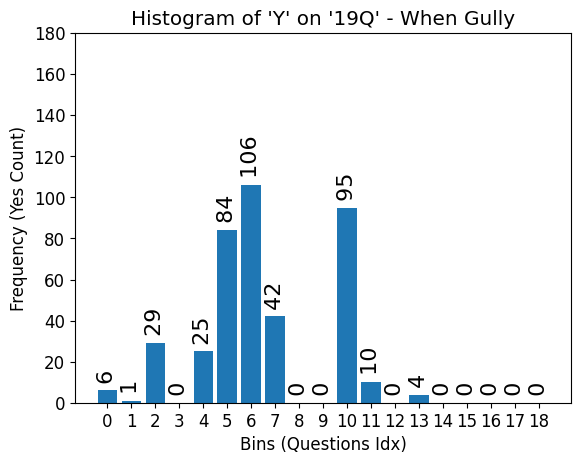

In [82]:
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

fig, ax = plt.subplots()
values = np.linspace(0, num_questions-1, num_questions)
bars = ax.bar(values, histogram_gully_values)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, " "+str(yval), va='bottom', ha='center', rotation=90, fontsize=16, horizontalalignment='center')


plt.xticks(np.arange(num_questions))
plt.xlabel('Bins (Questions Idx)')
plt.ylabel('Frequency (Yes Count)')
plt.title("Histogram of 'Y' on '19Q' - When Gully")
plt.ylim([0,180])

plt.savefig("histogram_yes_when_gully_19.pdf", format="pdf")
plt.show()


#plt.hist(histogram_gully_values, bins=15, color='skyblue', edgecolor='black')



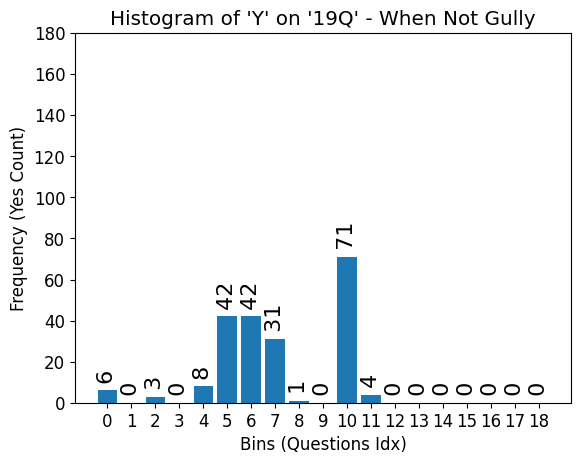

In [83]:
fig, ax = plt.subplots()
values = np.linspace(0, num_questions-1, num_questions)
bars = ax.bar(values, histogram_not_gully_values)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, " "+str(yval), va='bottom', ha='center', rotation=90, fontsize=16, horizontalalignment='center')
    #ax.text(bar.get_x() + bar.get_width() / 2, yval, str(yval), va='bottom', ha='center')


plt.xticks(np.arange(num_questions))
plt.xlabel('Bins (Questions Idx)')
plt.ylabel('Frequency (Yes Count)')
plt.title("Histogram of 'Y' on '19Q' - When Not Gully")
plt.ylim([0,180])

plt.savefig("histogram_yes_when_not_gully_19.pdf")
plt.show()


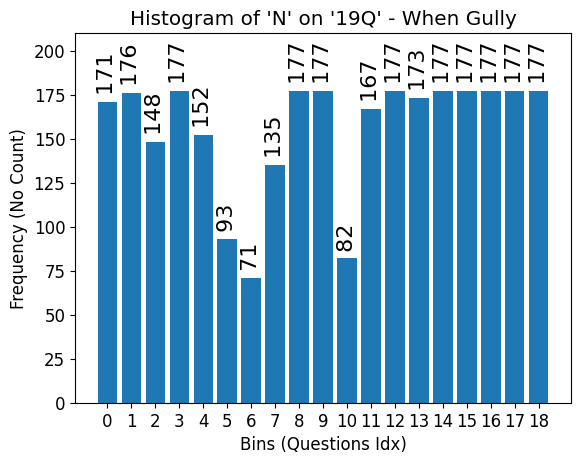

In [86]:
fig, ax = plt.subplots()
values = np.linspace(0, num_questions-1, num_questions)
bars = ax.bar(values, no_histogram_gully_values)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, " "+str(yval), va='bottom', ha='center', rotation=90, fontsize=16, horizontalalignment='center')
    #ax.text(bar.get_x() + bar.get_width() / 2, yval, str(yval), va='bottom', ha='center')


plt.xticks(np.arange(num_questions))
plt.xlabel('Bins (Questions Idx)')
plt.ylabel('Frequency (No Count)')
#plt.title('Histogram of No on the 15 Questions - When Gully')
plt.title("Histogram of 'N' on '19Q' - When Gully")
plt.ylim([0,210])

plt.savefig("histogram_no_when_gully_19.pdf")
plt.show()



#plt.hist(histogram_gully_values, bins=15, color='skyblue', edgecolor='black')



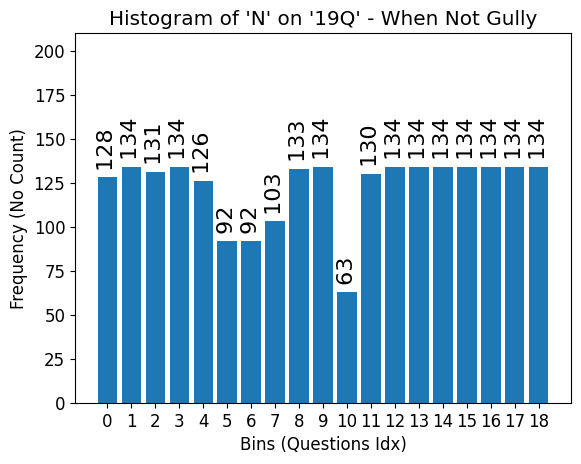

In [87]:
fig, ax = plt.subplots()
values = np.linspace(0, num_questions-1, num_questions)
bars = ax.bar(values, no_histogram_not_gully_values)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval, " "+str(yval), va='bottom', ha='center', rotation=90, fontsize=16, horizontalalignment='center')
    #ax.text(bar.get_x() + bar.get_width() / 2, yval, str(yval), va='bottom', ha='center')


plt.xticks(np.arange(num_questions))
plt.xlabel('Bins (Questions Idx)')
plt.ylabel('Frequency (No Count)')
#plt.title('Histogram of No on the 15 Questions - When Not Gully')
plt.title("Histogram of 'N' on '19Q' - When Not Gully")
plt.ylim([0,210])

plt.savefig("histogram_no_when_not_gully_19.pdf")
plt.show()
